In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
from utils.colors import colors_dictionary

import numpy as np 

from experiment_utils.largestconnectedcomponent import lcc_dataset
from utils.load_datasets import load_data

In [ ]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0}

In [2]:
from experiment_utils.curvatures_cuda import BF_curvature_undirected,JT_curvature,JL_curvature,AF_curvature
import torch_geometric as torch_geometric

In [3]:
plt.style.use('thesis_b5')
full_width, full_height = plt.rcParams['figure.figsize']

In [4]:
results_dir = "results_figures/"

In [5]:
dataset_names = ["Texas","Cornell","Wisconsin","Chameleon","Cora","Citeseer","Pubmed"]

In [22]:
def check_overflow(fig):
    """Warn if any artist extends beyond the figsize canvas."""
    renderer = fig.canvas.get_renderer()
    tight = fig.get_tightbbox(renderer)           # in inches
    w, h = fig.get_size_inches()

    # tight bbox coords are in inches from origin
    overflow = {
        'left':   -tight.x0,
        'right':  tight.x1 - w,
        'bottom': -tight.y0,
        'top':    tight.y1 - h,
    }
    problems = {k: v * 25.4 for k, v in overflow.items() if v > 0.01}  # >0.25mm tolerance

    if problems:
        for side, mm in problems.items():
            print(f"  ⚠ overflow {side}: {mm:.1f}mm")
    else:
        print("  ✓ everything fits within figsize")

In [199]:
plt.rcParams['xtick.major.pad'] = 1
plt.rcParams['ytick.major.pad'] = 1

### Curvature Distribution

In [ ]:
def curvatures_distributions(figsize,Curvature1,Curvature2,Curvature3,Curvature4,Curvature5,Curvature6,edge_index,colorlabels,labels ,title:str):
    FigCurvature,axCurvature = plt.subplot_mosaic([['h1','h2','h3','h4'],
                                                   ['h5','h5','h6','h6']],
                                  figsize=figsize,
                                  gridspec_kw = {'width_ratios':[1,1,1,1],'height_ratios': [1,0.7],'hspace':0.2,'wspace':0.1},dpi =450)
                                  #constrained_layout = True)

    FigCurvature.subplots_adjust(left=0.15, right=0.97, bottom=0.18, top=0.95)
    sp = FigCurvature.subplotpars
    center_x = (sp.left + sp.right) / 2
    center_y = (sp.bottom + sp.top) / 2

    nh1, bins, patches1 = axCurvature['h1'].hist(Curvature1[edge_index],bins = np.linspace(-2,4,41),linewidth=0.2,edgecolor = 'black',color = colors_dictionary[colorlabels[0]],label = labels[0],rwidth=0.7)
    ax1 =  axCurvature['h1'].inset_axes([0.59, 0.65 , 0.35, 0.25])
    nax1, bins, patches = ax1.hist(Curvature1[edge_index][torch.where(Curvature1[edge_index] < -0.5)],bins = np.linspace(-2,4,41),color = colors_dictionary[colorlabels[0]],linewidth=0.1,edgecolor = 'black')
    ax1.set_xlim(-2,-0.5)


    nh2, bins, patches2 = axCurvature['h2'].hist(Curvature2[edge_index],bins = np.linspace(-2,4,41),linewidth=0.2,edgecolor = 'black',color = colors_dictionary[colorlabels[1]],label = labels[1],rwidth=0.7)
    ax2 =  axCurvature['h2'].inset_axes([0.59, 0.65 , 0.35, 0.25])
    nax2, bins, patches = ax2.hist(Curvature2[edge_index][torch.where(Curvature2[edge_index] < -0.5)],bins = np.linspace(-2,4,41),color = colors_dictionary[colorlabels[1]],linewidth=0.1,edgecolor = 'black')
    ax2.set_xlim(-2,-0.5)


    nh3, bins, patches3 = axCurvature['h3'].hist(Curvature3[edge_index],bins = np.linspace(-2,4,41),linewidth=0.2,edgecolor = 'black',color = colors_dictionary[colorlabels[2]],label = labels[2],rwidth=0.7)
    
    ax3 =  axCurvature['h3'].inset_axes([0.59, 0.65 , 0.35, 0.25])
    nax3, bins, patches = ax3.hist(Curvature3[edge_index][torch.where(Curvature3[edge_index] < -0.5)],bins = np.linspace(-2,4,41),color = colors_dictionary[colorlabels[2]],linewidth=0.1,edgecolor = 'black')
    ax3.set_xlim(-2,-0.5)

    
    nh4, bins, patches4 = axCurvature['h4'].hist(Curvature4[edge_index],bins = np.linspace(-2,4,41),linewidth=0.2,edgecolor = 'black',color = colors_dictionary[colorlabels[3]],label = labels[3],rwidth=0.7)

    ax4 =  axCurvature['h4'].inset_axes([0.59, 0.65 , 0.35, 0.25])
    nax4, bins, patches = ax4.hist(Curvature4[edge_index][torch.where(Curvature4[edge_index] < -0.5)],bins = np.linspace(-2,4,41),color = colors_dictionary[colorlabels[3]],linewidth=0.1,edgecolor = 'black')
    ax4.set_xlim(-2,-0.5)

    
    #

    if title == "Chameleon":
         n, bins, patches6 = axCurvature['h6'].hist(Curvature6[edge_index],bins = np.linspace(-110,9000,800),
                                              color = colors_dictionary[colorlabels[5]],rwidth=0.7,
                                              label = labels[5])
         nh4, bins, patches5 = axCurvature['h5'].hist(Curvature5[edge_index],bins = np.linspace(-110,80,180),
                                              color = colors_dictionary[colorlabels[4]],rwidth=0.7,
                                              label = labels[4])
    else:
         n, bins, patches6 = axCurvature['h6'].hist(Curvature6[edge_index],bins = np.linspace(-110,10,100),
                                              linewidth=0.2,edgecolor = 'black',color = colors_dictionary[colorlabels[5]],rwidth=0.7,
                                              label = labels[5])
         nh4, bins, patches5 = axCurvature['h5'].hist(Curvature5[edge_index],bins = np.linspace(-110,10,100),
                                              linewidth=0.2,edgecolor = 'black',color = colors_dictionary[colorlabels[4]],rwidth=0.7,
                                              label = labels[4])
    patch = [patches1[0],patches2[0],patches3[0],patches4[0],patches5[0],patches6[0]]
    labs = [l.get_label() for l in patch]
    FigCurvature.legend(patch, labs,
                        loc='lower center',
                        ncol=6,
                        columnspacing=1.2,
                        bbox_to_anchor=(center_x, 0.01),
                        bbox_transform=FigCurvature.transFigure)

    for i in range(4):
        axCurvature['h'+str(i+1)].set_xticks([-2,0,4])
        if title == "Chameleon":
            axCurvature['h'+str(i+1)].set_xlim(-2.2,9)
        if title == "Cora" or title =="Citeseer":
            axCurvature['h'+str(i+1)].set_xlim(-2.2,6.5)
    
    axCurvature['h1'].set_ylabel("Count",labelpad=0.5)
    axCurvature['h5'].set_ylabel("Count",labelpad=0.5)
    axCurvature['h1'].sharey(axCurvature['h2'])
    axCurvature['h2'].sharey(axCurvature['h3'])
    axCurvature['h3'].sharey(axCurvature['h4'])

    axCurvature['h2'].set_yticklabels([])
    axCurvature['h3'].set_yticklabels([])
    axCurvature['h4'].set_yticklabels([])
    
    axCurvature['h1'].set_ylim(0,max([max(nh1),max(nh2),max(nh3),max(nh4)])+3)
    
    ax1.sharey(ax2)
    ax2.sharey(ax3)
    ax3.sharey(ax4)
    ax2.set_yticklabels([])
    ax3.set_yticklabels([])
    ax1.set_ylim(0,max([max(nax1),max(nax2),max(nax3),max(nax4)])+5)
    ax1.set_xlim(-2,-0.5)
    

    axCurvature['h5'].sharey(axCurvature['h6'])
    [label.set_visible(False) for label in axCurvature['h6'].get_yticklabels()]

    FigCurvature.text(0.01, sp.top, 
            r"$\mathbf{" + title + "}$",
            fontsize=11, ha='left', va='top')
    
    check_overflow(FigCurvature)
    FigCurvature.savefig(os.path.join(results_dir,"curvatures_comparison_" + title + ".pdf"),format = 'pdf')#,bbox_inches='tight')

In [314]:
curvatures = ["BFc","BFc_3","BFc_mod","JLc","AFc_3","AFc_4"]

/home/flortori/research_repositories/Revisiting-Graph-Curvature-Rewiring/.venv/lib/python3.12/site-packages/torch_geometric/data/in_memory_dataset.py:131: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])` to allowlist this global.
  out = fs.torch_load(path)
/home/flortori/research_repositories/Revisiting-Graph-Curvature-Rewiring/experiment_utils/largestconnectedcomponent.py:96: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  x_new = dataset.data.x[lcc]
/home/flortori/research_repositories/Revisiting-Graph-Curvature-R

  ✓ everything fits within figsize


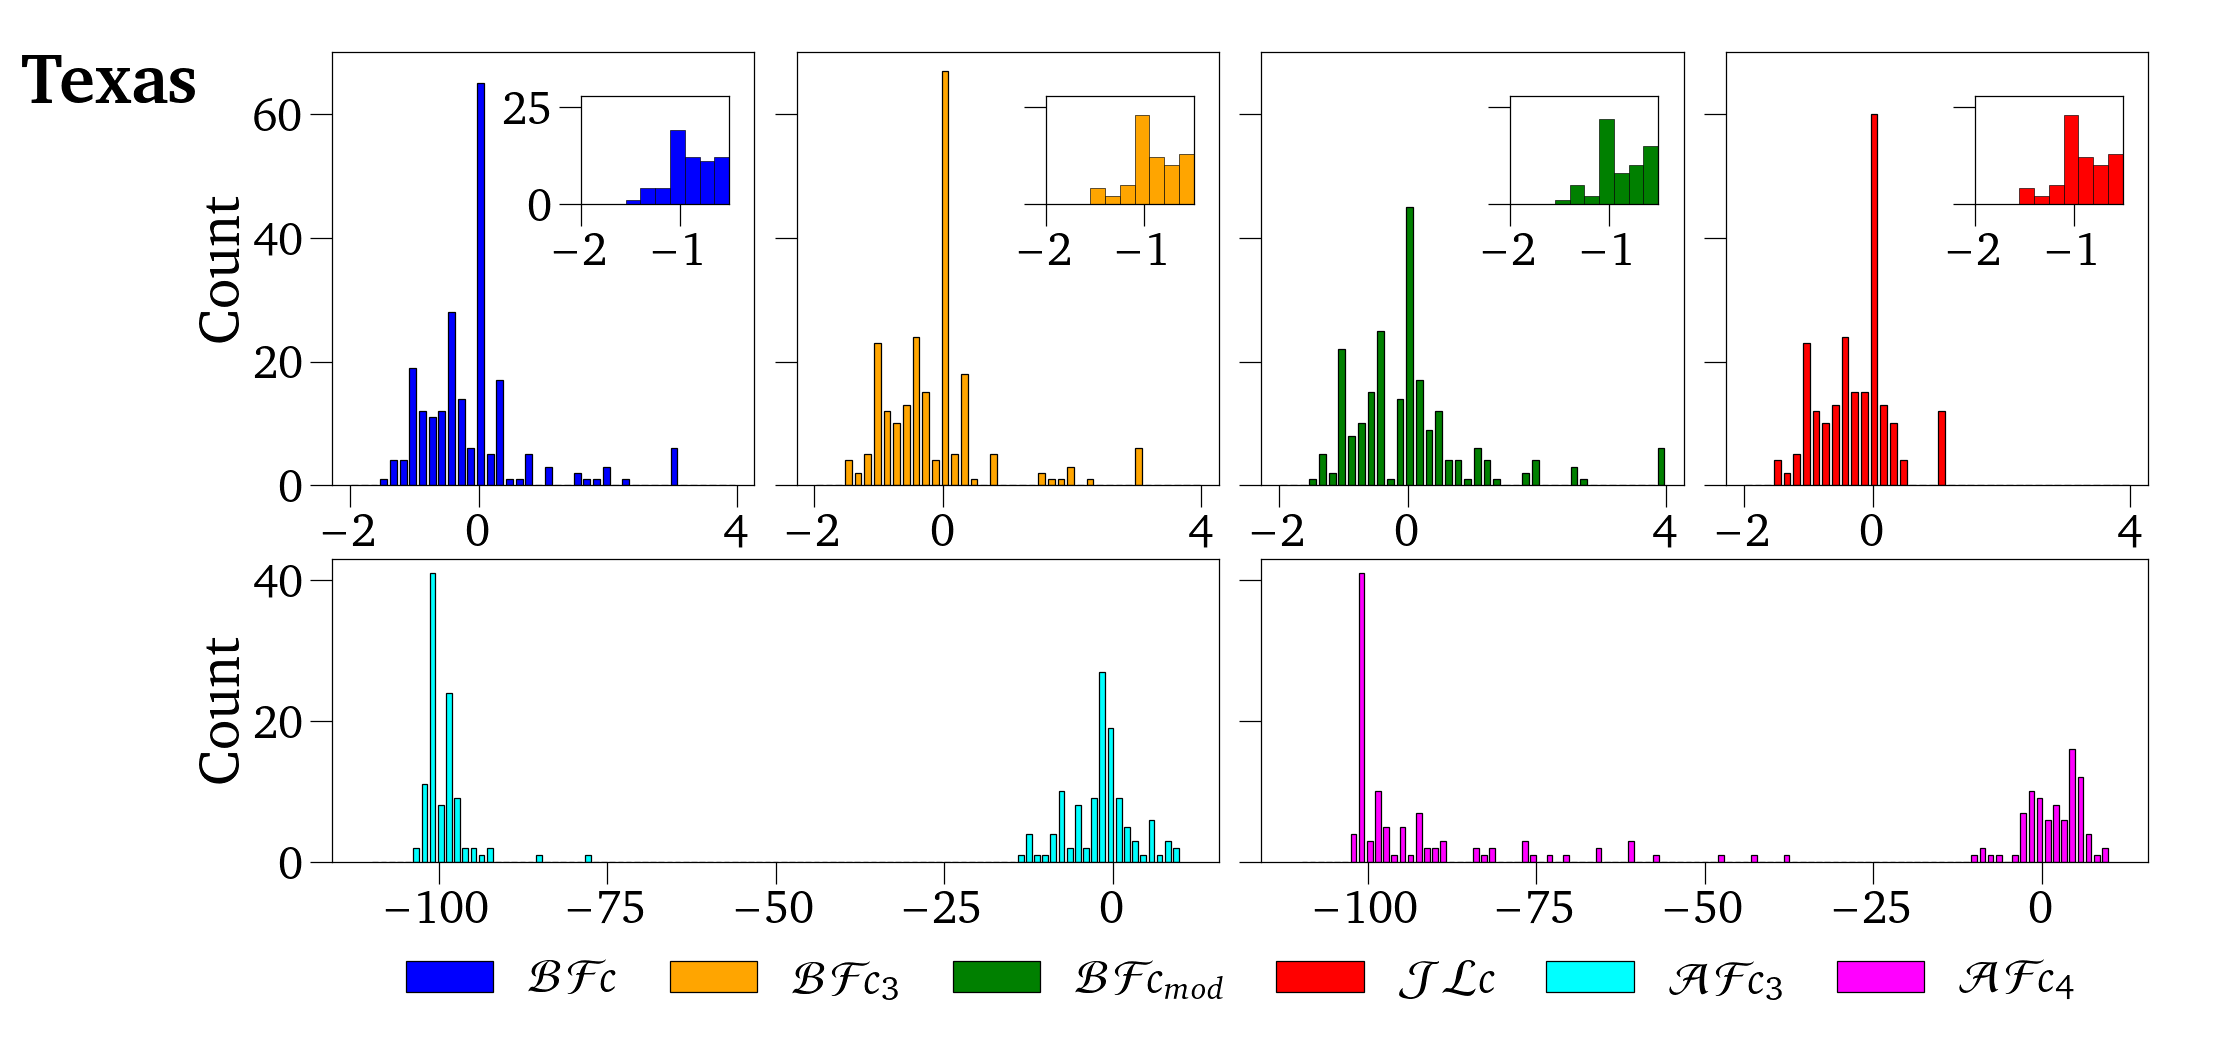

In [315]:
for dataset_name in dataset_names[:1]:
    curvature_matrices = {}

    dataset,_,_ = load_data(dataset_name)
    dataset_lcc = lcc_dataset(dataset, to_undirected = True)
    data_lcc = dataset_lcc[0]

    G_lcc = torch_geometric.utils.to_networkx(data_lcc)
    G_lcc = G_lcc.to_undirected()

    edge_index = data_lcc.edge_index.clone()
    

    A = torch_geometric.utils.to_dense_adj(edge_index)[0]
    

    A_upper = np.triu(A)
    edge_index_upper = np.where(A_upper)

    A = A.cuda()
    edge_index = edge_index.cuda() 
    N = A.shape[0]
    C = torch.zeros(N, N).cuda()


    for curvature_type in curvatures:
        if curvature_type == "BFc":
            C = BF_curvature_undirected(A,edge_index ,C=C,fcc = True)
        elif curvature_type == "BFc_3":
            C = BF_curvature_undirected(A,edge_index ,C=C,fcc = False)
        elif curvature_type == "BFc_mod":
            C = JT_curvature(A,C=C)
        elif curvature_type == "JLc":
            C = JL_curvature(A,C=C)
        elif curvature_type == "AFc_3":
            C = AF_curvature(A,3,C=C)
        elif curvature_type == "AFc_4":
            C = AF_curvature(A,4,C=C)

        curvature_matrices[curvature_type] = C.cpu()
        
    curvatures_distributions((full_width,full_height/3),
                             curvature_matrices["BFc"],curvature_matrices["BFc_3"],curvature_matrices["BFc_mod"],curvature_matrices["JLc"],curvature_matrices["AFc_3"],curvature_matrices["AFc_4"],
                         edge_index_upper,
                         ["BFc","BFc_no4cycle","BFc_mod","JLc","AFc_3","AFc_4"],
                         [r"$\mathcal{BF}c$",r"$\mathcal{BF}c_{3}$",r"$\mathcal{BF}c_{mod}$",r"$\mathcal{JL}c$",r"$\mathcal{AF}c_3$",r"$\mathcal{AF}c_4$"],
                         dataset_name)
    